In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append("..")   # repo root
from src.setup_db import weatherDB
from pathlib import Path
import lightgbm as lgb
import matplotlib.pyplot as plt


# get database
db_path = Path.cwd().parent / "weather.db"
db = weatherDB(f"sqlite:///{db_path}")

In [2]:
df = db.get_weather_data()

In [3]:
df

,id,time,temperature_2m,relativehumidity_2m,rain,snowfall,windspeed_10m,winddirection_10m,soil_temperature_0_to_7cm
0,1,2024-09-01 00:00:00,15.5,75.0,0.0,0.0,13.9,69.0,19.3
1,2,2024-09-01 01:00:00,14.8,80.0,0.0,0.0,13.4,66.0,18.0
2,3,2024-09-01 02:00:00,14.5,82.0,0.0,0.0,13.4,66.0,17.7
3,4,2024-09-01 03:00:00,14.2,83.0,0.0,0.0,12.5,72.0,17.5
4,5,2024-09-01 04:00:00,14.0,85.0,0.0,0.0,13.3,71.0,17.2
...,...,...,...,...,...,...,...,...,...
17611,17612,2026-09-04 19:00:00,18.8,88.0,0.4,0.0,19.8,269.0,19.8
17612,17613,2026-09-04 20:00:00,18.4,88.0,0.3,0.0,21.9,276.0,19.3
17613,17614,2026-09-04 21:00:00,17.6,86.0,0.0,0.0,19.9,275.0,18.8
17614,17615,2026-09-04 22:00:00,17.0,84.0,0.1,0.0,19.8,271.0,18.2


In [4]:
# sort by time index for sorted training indices (no future leakage)
df = df.sort_values("time").reset_index(drop=True)

# get time features, sin cos since time is cyclical
df["hour"] = df["time"].dt.hour
df["dayofyear"] = df["time"].dt.dayofyear
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# all features
feature_cols = [
    "relativehumidity_2m", "rain", "snowfall", "windspeed_10m",
    "winddirection_10m", "soil_temperature_0_to_7cm",
    "hour_sin", "hour_cos", "dayofyear",
]

# features, target
X = df[feature_cols]
y = df["temperature_2m"]

# time-ordered split to avoid future leakage (85% training data)
split = int(len(df) * 0.85)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [5]:
X_train.head()

,relativehumidity_2m,rain,snowfall,windspeed_10m,winddirection_10m,soil_temperature_0_to_7cm,hour_sin,hour_cos,dayofyear
0,75.0,0.0,0.0,13.9,69.0,19.3,0.000000,1.000000,245
1,80.0,0.0,0.0,13.4,66.0,18.0,0.258819,0.965926,245
2,82.0,0.0,0.0,13.4,66.0,17.7,0.500000,0.866025,245
3,83.0,0.0,0.0,12.5,72.0,17.5,0.707107,0.707107,245
4,85.0,0.0,0.0,13.3,71.0,17.2,0.866025,0.500000,245


In [6]:
# estimate and evaluate
model = lgb.LGBMRegressor(n_estimators=200, random_state=125)
model.fit(X_train, y_train)

preds = model.predict(X_test)
mae = np.mean(np.abs(preds - y_test))
print(f"Test MAE: {mae:.2f} °C")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000571 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1201
[LightGBM] [Info] Number of data points in the train set: 14973, number of used features: 9
[LightGBM] [Info] Start training from score 9.314967


Test MAE: 1.14 °C


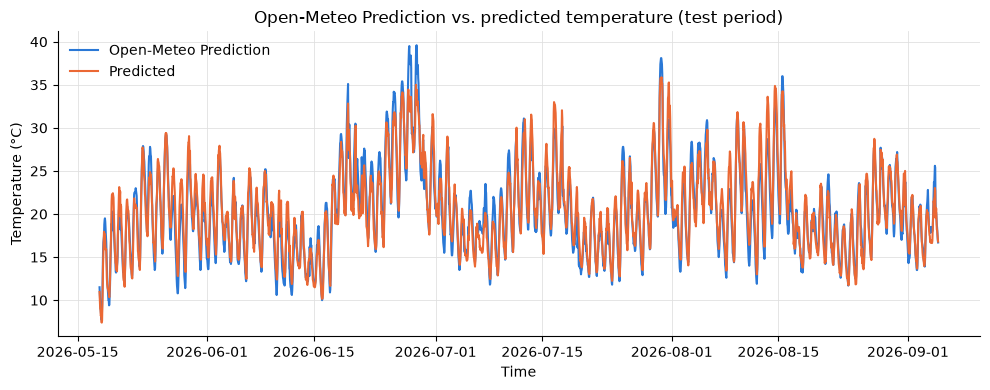

In [7]:
# Predicted vs. Open-Meteo Prediction over test period
test_time = df["time"].iloc[split:]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(test_time, y_test, color="#2a78d6", linewidth=1.5, label="Open-Meteo Prediction")
ax.plot(test_time, preds, color="#eb6834", linewidth=1.5, label="Predicted")
ax.set_xlabel("Time")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Open-Meteo Prediction vs. predicted temperature (test period)")
ax.grid(True, color="#e0e0e0", linewidth=0.6)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

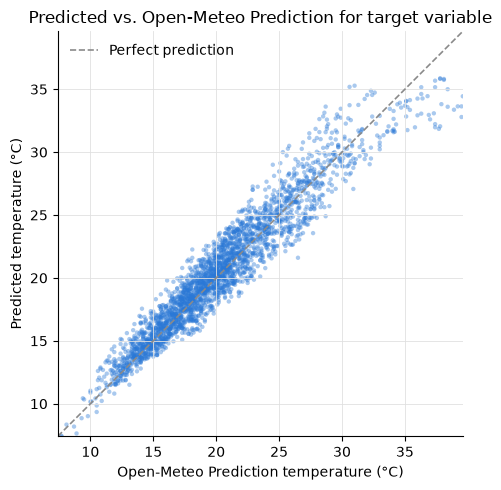

In [8]:
# predicted vs. Open-Meteo Prediction for target variable
lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, preds, color="#2a78d6", s=10, alpha=0.4, edgecolors="none")
ax.plot(lims, lims, color="#8a8a8a", linewidth=1.2, linestyle="--", label="Perfect prediction")
ax.set_xlabel("Open-Meteo Prediction temperature (°C)")
ax.set_ylabel("Predicted temperature (°C)")
ax.set_title("Predicted vs. Open-Meteo Prediction for target variable")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.grid(True, color="#e0e0e0", linewidth=0.6)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()

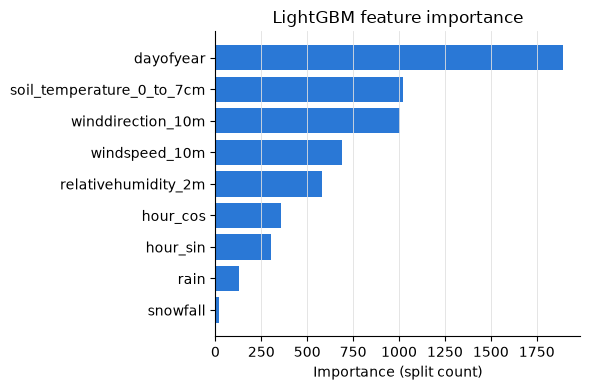

In [9]:
# Feature importance
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(importance.index, importance.values, color="#2a78d6")
ax.set_xlabel("Importance (split count)")
ax.set_title("LightGBM feature importance")
ax.grid(True, axis="x", color="#e0e0e0", linewidth=0.6)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
plt.show()